**Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.cluster import KMeans

**Uploading & Loading Fact Table**

In [ ]:
from google.colab import files
upload=files.upload()

Saving fact_table.csv to fact_table (2).csv


In [ ]:
data=pd.read_csv('fact_table.csv', encoding='Latin1')

In [ ]:
data.head(5)

,Title,keyword,keyword_id,Position,Previous position,Traffic,Traffic_id,CPC,Traffic Cost,traffic_cost_id,Last Seen,Competition,Search Volume,Number of Results,Keyword Difficulty
0,PMP® Exam & Certification | Flat 40% Off - Enr...,pmp certification,1,1,1,4253,1,3.76,15991,1,31-12-2024,0.60,90500,166000000,78.0
1,PMP® Exam & Certification | Confidently Ace Th...,pmp certification,1,1,1,4253,1,3.76,15991,1,01-01-2025,0.60,90500,172000000,78.0
2,PMP® Training & Exam | Special Offer: Get $400...,pmp certification,1,1,2,1176,2,3.82,4492,2,14-01-2025,0.65,90500,154000000,77.0
3,CSM Scrum Master Course Online | Today's Offer...,scrum master certification,2,1,1,850,2,3.21,2728,2,10-01-2025,0.64,18100,32000000,70.0
4,PMP® Certification | Ace PMP Exam in 1st Attempt,pmp certification,1,3,3,814,2,3.82,3109,2,07-01-2025,0.65,90500,165000000,78.0


**Data Information & Preprocessing**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Title               199 non-null    object 
 1   keyword             199 non-null    object 
 2   keyword_id          199 non-null    int64  
 3   Position            199 non-null    int64  
 4   Previous position   199 non-null    int64  
 5   Traffic             199 non-null    int64  
 6   Traffic_id          199 non-null    int64  
 7   CPC                 199 non-null    float64
 8   Traffic Cost        199 non-null    int64  
 9   traffic_cost_id     199 non-null    int64  
 10  Last Seen           199 non-null    object 
 11  Competition         199 non-null    float64
 12  Search Volume       199 non-null    int64  
 13  Number of Results   199 non-null    int64  
 14  Keyword Difficulty  198 non-null    float64
dtypes: float64(3), int64(9), object(3)
memory usage: 23.4+ KB

In [ ]:
data.isnull().sum()

,0
Title,0
keyword,0
keyword_id,0
Position,0
Previous position,0
Traffic,0
Traffic_id,0
CPC,0
Traffic Cost,0
traffic_cost_id,0


In [ ]:
data=data.fillna(0)
data.isnull().sum()

,0
Title,0
keyword,0
keyword_id,0
Position,0
Previous position,0
Traffic,0
Traffic_id,0
CPC,0
Traffic Cost,0
traffic_cost_id,0


In [ ]:
data.describe()

,keyword_id,Position,Previous position,Traffic,Traffic_id,CPC,Traffic Cost,traffic_cost_id,Competition,Search Volume,Number of Results,Keyword Difficulty
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,1.990000e+02,199.000000
mean,4.165829,2.532663,2.391960,93.829146,2.954774,3.916985,325.819095,2.899497,0.381658,4711.608040,4.575325e+07,48.502513
std,3.021412,1.526761,1.559311,446.718734,0.252192,3.853916,1671.621365,0.333257,0.198629,16003.015228,1.462253e+08,17.260884
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,30.000000,0.000000e+00,0.000000
25%,1.000000,1.000000,1.000000,0.500000,3.000000,2.310000,0.000000,3.000000,0.185000,70.000000,2.750000e+06,37.000000
50%,4.000000,2.000000,2.000000,3.000000,3.000000,3.210000,7.000000,3.000000,0.410000,170.000000,5.570000e+06,47.000000
75%,5.000000,4.000000,4.000000,20.000000,3.000000,4.485000,48.000000,3.000000,0.520000,1600.000000,3.170000e+07,60.000000
max,11.000000,6.000000,6.000000,4253.000000,3.000000,46.860000,15991.000000,3.000000,0.950000,90500.000000,1.400000e+09,97.000000


In [ ]:
data.describe(include='object')

,Title,keyword,Last Seen
count,199,199,199
unique,108,129,30
top,CSM Scrum Master Course Online | Today's Offer...,simplilearn,31-12-2024
freq,11,34,23


In [ ]:
data.rename(columns={'traffic_cost_id': 'cost_id'}, inplace=True)



**Loading Lookup Tables**



**Keyword Lookup Table**

In [ ]:
file2=files.upload()


Saving keyword.csv to keyword (1).csv


In [ ]:
keyword_df=pd.read_csv('keyword.csv', encoding='Latin1')

**Traffic Lookup table**

In [ ]:
file2=files.upload()

Saving traffic.csv to traffic (1).csv


In [ ]:
keyword_df.head(3)

,keyword_id,keyword_name
0,1,pmp
1,2,scrum
2,3,agile


**Traffic Cost lookup table**

In [ ]:
traffic_df=pd.read_csv('traffic.csv', encoding='Latin1')
traffic_df.head(3)

,Traffic_id,min_traffic,max_traffic,traffic_group
0,1,1500,5000,High
1,2,500,1500,Medium
2,3,0,500,Low


In [ ]:
file3=files.upload()

Saving traffic_cost.csv to traffic_cost (1).csv


In [ ]:
traffic_cost_df=pd.read_csv('traffic_cost.csv', encoding='Latin1')
traffic_cost_df.head(3)

,cost_id,min_cost,max_cost,cost_level
0,1,5000,20000,High
1,2,1000,5000,Medium
2,3,0,1000,Low


**Merging Lookup Tables with Fact Table**

In [ ]:
data = data.merge(keyword_df, on='keyword_id', how='left')

In [ ]:
data = data.merge(traffic_df, on='Traffic_id', how='left')

In [ ]:
data = data.merge(traffic_cost_df, on='cost_id', how='left')

**Dropping Columns**

In [ ]:
data.drop(columns=['min_traffic','max_traffic', 'min_cost','max_cost'], inplace=True)

In [ ]:
data.head(3)

,Title,keyword,keyword_id,Position,Previous position,Traffic,Traffic_id,CPC,Traffic Cost,cost_id,Last Seen,Competition,Search Volume,Number of Results,Keyword Difficulty,keyword_name,traffic_group,cost_level
0,PMP® Exam & Certification | Flat 40% Off - Enr...,pmp certification,1,1,1,4253,1,3.76,15991,1,31-12-2024,0.60,90500,166000000,78.0,pmp,High,High
1,PMP® Exam & Certification | Confidently Ace Th...,pmp certification,1,1,1,4253,1,3.76,15991,1,01-01-2025,0.60,90500,172000000,78.0,pmp,High,High
2,PMP® Training & Exam | Special Offer: Get $400...,pmp certification,1,1,2,1176,2,3.82,4492,2,14-01-2025,0.65,90500,154000000,77.0,pmp,Medium,Medium


**Exploratory Data Analysis**

Correlation of Numerical Variables

<Axes: >

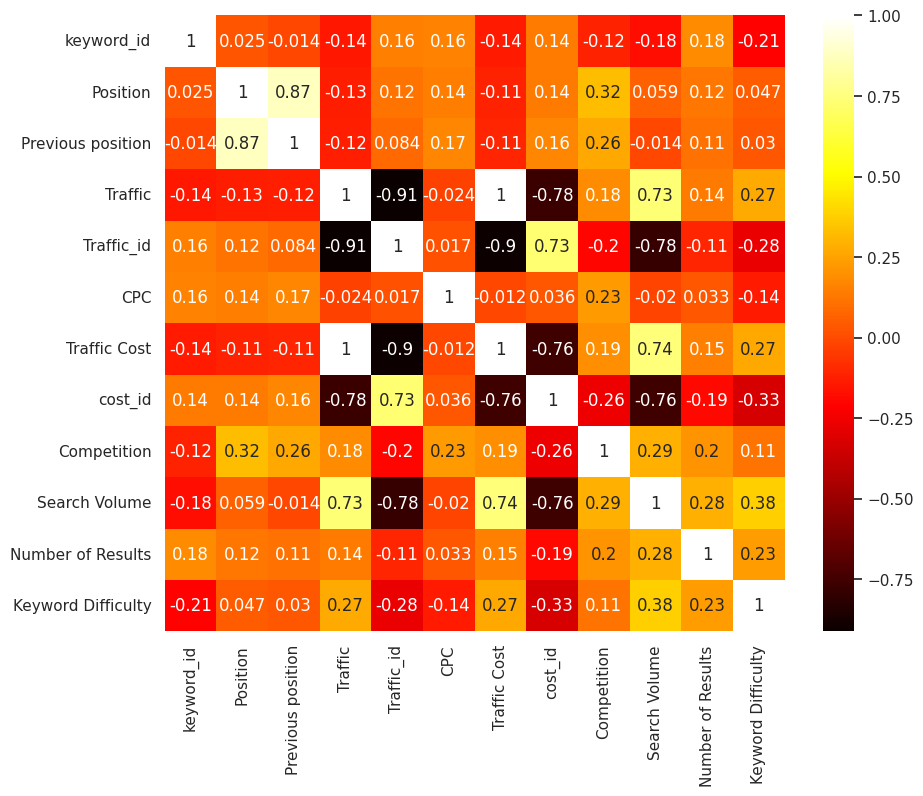

In [ ]:
sns.set(rc={'figure.figsize':(10,8)})
numeric_data = data.select_dtypes(include=['number'])
heatmap=sns.heatmap(numeric_data.corr(),cmap='hot', annot=True)
heatmap

**Insights from correlation heatmap:**

**Position and Previous Position** have a perfect correlation (1.0), indicating that keyword rankings have remained almost unchanged over time.

**Traffic and Traffic Cost** also show a perfect correlation (1.0), meaning the cost associated with traffic increases proportionally with the amount of traffic generated.

Additionally, **Traffic and Search Volumec traffic cost and search volume** exhibit a strong positive correlation, suggesting that keywords with higher search demand tend to drive higher website traffic.


**k-means Clustering**

In [ ]:
inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(numeric_data )
    inertia.append(algorithm.inertia_)

In [ ]:
import warnings
warnings.filterwarnings('ignore')


**Elbow Method:**

The Elbow Method is used to determine the optimal number of clusters in K-Means clustering by identifying the point where the decrease in inertia starts to slow down.

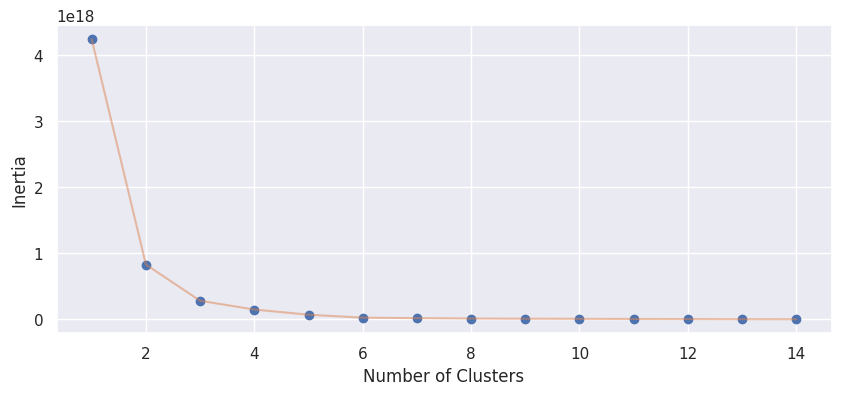

In [ ]:
import plotly as py
plt.figure(1 , figsize = (10 ,4))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

In [ ]:
algorithm = (KMeans(n_clusters = 3 ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(numeric_data)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

**Adding predicted clusters to numeric data**

In [ ]:
numeric_data['cluster'] = labels1

In [ ]:
numeric_data['cluster'].value_counts()

,count
cluster,
0,179
2,17
1,3


In [ ]:
numeric_data.groupby('cluster')[['Traffic','CPC','Search Volume','Competition']].min()

,Traffic,CPC,Search Volume,Competition
cluster,,,,
0,0,0.00,30,0.00
1,85,3.76,6600,0.41
2,0,0.00,70,0.26


In [ ]:
numeric_data.groupby('cluster')[['Traffic','CPC','Search Volume','Competition']].max()

,Traffic,CPC,Search Volume,Competition
cluster,,,,
0,850,46.86,18100,0.95
1,247,6.49,49500,0.68
2,4253,9.39,90500,0.72


In [ ]:
numeric_data.groupby('cluster')[['Traffic','CPC','Search Volume','Competition']].mean()

,Traffic,CPC,Search Volume,Competition
cluster,,,,
0,34.368715,3.909218,1628.994413,0.364693
1,152.666667,4.673333,24733.333333,0.563333
2,709.529412,3.865294,33636.470588,0.528235


The clustering analysis segments keywords into three groups:

**Cluster 0** - high-demand keywords that drive the majority of traffic and search interest

**Cluster 1** -  low-demand niche keywords

**Cluster 2** - commercially competitive keywords with higher CPC

**Adding clusters into original data**

In [ ]:
data['cluster']=numeric_data['cluster']

**low-demand niche keywords**

In [ ]:
data[data['cluster']==1]['keyword_name'].value_counts()

,count
keyword_name,
project management,2
others,1




Advertisements targeting keywords such as **project management **and similar terms represent a low-demand niche segment, indicating relatively lower competition and more specific audience targeting compared to high-demand keywords

**Commercially competitive keywords with higher CPC**

In [ ]:
data[data['cluster']==2]['keyword_name'].value_counts()

,count
keyword_name,
pmp,12
aws,2
others,2
project management,1


**PMP, AWS, and Project Management **are highly competitive commercial keywords, reflected by their higher cost-per-click (CPC) values, indicating strong advertiser demand.

**High-demand keywords that drive the majority of traffic and search interest**

In [ ]:
data[data['cluster']==0]['keyword_name'].value_counts()

,count
keyword_name,
simplilearn,55
pmp,39
scrum,25
itil,23
others,11
togaf,9
project management,6
agile,3
capm,3


Keywords such as **Simplilearn, PMP, ITIL, and Scrum** generate the majority of traffic, indicating high search demand and strong user interest.

In [ ]:
data.groupby('cluster')['keyword_name'].unique().apply(list)

,keyword_name
cluster,
0,"[scrum, itil, csm, simplilearn, others, capm, ..."
1,"[project management , others]"
2,"[pmp, aws, project management , others]"


**Keyword Clusters Distribution**

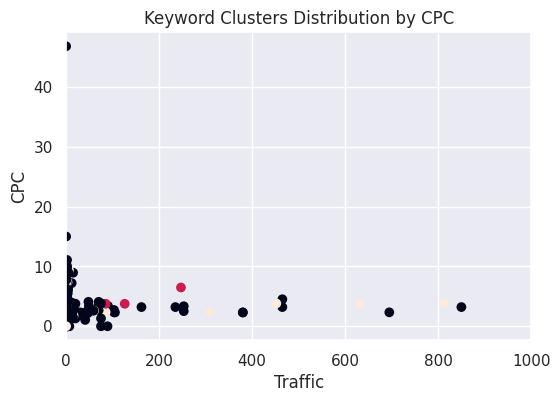

In [ ]:
plt.figure(1 , figsize = (6 ,4))
plt.scatter(data['Traffic'], data['CPC'], c=data['cluster'])
plt.xlabel("Traffic")
plt.ylabel("CPC")
plt.title("Keyword Clusters Distribution by CPC")
plt.xlim(0, 1000)
plt.show()


Most keywords fall within a low CPC range, while a few high-CPC outliers indicate highly competitive and high-value search terms.”

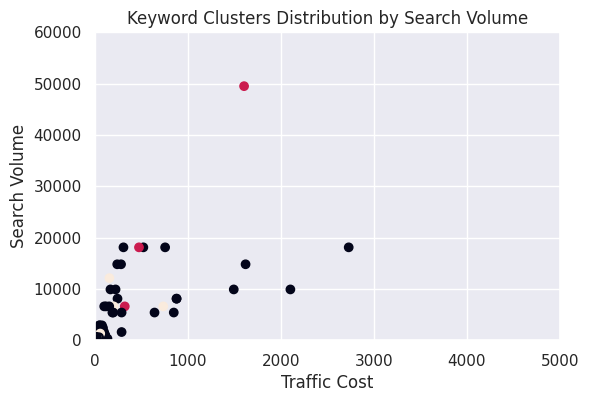

In [ ]:
plt.figure(1 , figsize = (6 ,4))
plt.scatter(data['Traffic Cost'], data['Search Volume'], c=data['cluster'])
plt.xlabel("Traffic Cost")
plt.ylabel("Search Volume")
plt.title("Keyword Clusters Distribution by Search Volume")
plt.xlim(0, 5000)
plt.ylim(0, 60000)
plt.show()


Most keywords fall within a low traffic cost range, while a few high-search-volume keywords present strong opportunities for high traffic with optimized ad spend.

**Recommendations And Suggestions:**

1. **Prioritize High-Demand Keywords:** Increase focus and budget allocation on **Simplilearn, PMP, ITIL, and Scrum** as they drive the majority of traffic and search interest.

2. **Optimize Bidding for Competitive Keywords:**
Implement cost-efficient bidding strategies for **PMP, AWS, and Project Management** to manage high CPC while maintaining ad visibility.

3. **Leverage Supporting Keywords:**
Expand campaigns using **Agile, CAPM, TOGAF, and CSM** to target niche audiences and diversify traffic sources.